---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [398]:
# this is your first code cell, add more cells for code and mardown as needed
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from datetime import datetime
import plotly.express as px
import seaborn as sns

## Exploring `sessions.csv`

In [399]:
# TASK 1a: SESSIONS.CSV
df_sessions = pd.read_csv("data/sessions.csv")
display(df_sessions)
display (f"The shape of the dataframe is: {df_sessions.shape}")
columns = [*df_sessions.columns]
print(f"Columns are: {columns}")
print("\nGiven below are descriptive stats on the numerical columns\n")
df_sessions.describe()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...
22820,SES022821,VWR00856,STR0005,SM00083,2024-01-16 18:51:00,2024-01-16 22:17:00,206,31,0,False,False
22821,SES022822,VWR00985,STR0013,SM00200,2024-01-08 20:28:00,2024-01-08 20:52:00,24,1,0,False,False
22822,SES022823,VWR00645,STR0045,SM00711,2024-03-26 04:15:00,2024-03-26 04:58:00,43,1,0,False,False
22823,SES022824,VWR00291,STR0005,SM00078,2024-01-11 20:02:00,2024-01-11 21:01:00,59,2,0,False,False


'The shape of the dataframe is: (22825, 11)'

Columns are: ['session_id', 'viewer_id', 'streamer_id', 'stream_id', 'started_at', 'ended_at', 'duration_mins', 'chat_messages_sent', 'bits_cheered', 'followed_during', 'subscribed_during']

Given below are descriptive stats on the numerical columns



,duration_mins,chat_messages_sent,bits_cheered
count,22825.000000,22825.000000,22825.000000
mean,59.051303,6.442629,398.425323
std,60.383979,46.576309,1571.528658
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,39.000000,1.000000,0.000000
75%,83.000000,5.000000,0.000000
max,443.000000,1987.000000,10000.000000


### Task 1a: Summarizing sessions.csv

Since every file is converted to a dataframe and is being treated like a table, I will often use the term table and file interchangably (within reason) in this assignment.

#### Overview
This table contains information about individual viewing sesssions.

#### Table shape
- **Rows**: There are 22825 rows (22824 entries, since one row is for the column headings.)
- **Columns**: There are 11 columns. They are described below.

##### Columns description
|Column Header | Decription | Type of data | Comments |
|--------------|------------|--------------|----------|
| `session_id` | unique identifier for the inidividual session | Categorical (nominal) | N/A |
| `viewer_id` | unique identifer for the viewer (consistent across other files) | Cateogrical (nominal) | N/A |
| `streamer_id` | unique identifer for the viewer (consistent across other files) | Categorical (nominal) | N/A |
| `stream_id` | unique identifer for the stream session (consistent across other files) | Categorical (nominal) | N/A |
| `started_at` | Time and date the stream started. Format: YYYY-MM-DD HH:MM:SS | Numerical (interval) | I will create another column with this in unix timestamp to make calculations easier |
| `ended_at` | Time and date the stream ended. Format: YYYY-MM-DD HH:MM:SS | Numerical (interval) | I will create another column with this in unix timestamp to make calculations easier
| `duration_mins` | The length of the stream in minutes. | Numerical (ratio) | N/A |
| `chat_messages_sent` | The number of messages set on the chat | Numerical (ratio) | N/A |
| `bits_cheered` | The number bit cheers sent (a twitch currency) | Numerical (ratio) | N/A |
| `followed_during` | Boolean representing if the viewer followed the streamer during the session | Categorical (boolean) | N/A |
| `subscribed_during` | Boolean representing if the viewer subscribed the streamer during the session | Categorical (boolean) | N/A |


Below, I will convert the `started_at` and `ended_at` time to unix timestamp and do `describe()` again to see if any weird time is there.

In [400]:
# Task 1a: Continued, creating new columns with unix_timestamp
df_sessions["started_at_unix"] = (pd.to_datetime(df_sessions["started_at"]) - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")
started_at_unix = df_sessions.pop("started_at_unix")
df_sessions.insert(loc=5, column="started_at_unix_time", value=started_at_unix)

df_sessions["ended_at_unix"] = (pd.to_datetime(df_sessions["ended_at"]) - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")
ended_at_unix = df_sessions.pop("ended_at_unix")
df_sessions.insert(loc=7, column="ended_at_unix_time", value=ended_at_unix)
display(df_sessions)
df_sessions.describe()

,session_id,viewer_id,streamer_id,stream_id,started_at,started_at_unix_time,ended_at,ended_at_unix_time,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,1705605360,2024-01-18 20:28:00,1705609680,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,1704388260,2024-01-04 19:41:00,1704397260,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,1708009860,2024-02-15 16:53:00,1708015980,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,1705607940,2024-01-18 20:56:00,1705611360,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,1710878880,2024-03-19 20:22:00,1710879720,14,7,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22820,SES022821,VWR00856,STR0005,SM00083,2024-01-16 18:51:00,1705431060,2024-01-16 22:17:00,1705443420,206,31,0,False,False
22821,SES022822,VWR00985,STR0013,SM00200,2024-01-08 20:28:00,1704745680,2024-01-08 20:52:00,1704747120,24,1,0,False,False
22822,SES022823,VWR00645,STR0045,SM00711,2024-03-26 04:15:00,1711426500,2024-03-26 04:58:00,1711429080,43,1,0,False,False
22823,SES022824,VWR00291,STR0005,SM00078,2024-01-11 20:02:00,1705003320,2024-01-11 21:01:00,1705006860,59,2,0,False,False


,started_at_unix_time,ended_at_unix_time,duration_mins,chat_messages_sent,bits_cheered
count,2.282500e+04,2.282500e+04,22825.000000,22825.000000,22825.000000
mean,1.707894e+09,1.707898e+09,59.051303,6.442629,398.425323
std,2.247283e+06,2.247340e+06,60.383979,46.576309,1571.528658
min,1.704097e+09,1.704097e+09,0.000000,0.000000,0.000000
25%,1.706016e+09,1.706020e+09,15.000000,0.000000,0.000000
50%,1.707836e+09,1.707840e+09,39.000000,1.000000,0.000000
75%,1.709842e+09,1.709847e+09,83.000000,5.000000,0.000000
max,1.711848e+09,1.711850e+09,443.000000,1987.000000,10000.000000


## Exploring `streamers.csv`

In [401]:
# TASK 1b: STREAMERS.CSV
df_streamers = pd.read_csv("data/streamers.csv")
display(df_streamers)
display (f"The shape of the dataframe is: {df_streamers.shape}")
columns_streamers = [*df_streamers.columns] # this stringifies the items, sep in the list, separating them with a comma (https://www.geeksforgeeks.org/python/print-lists-in-python-4-different-ways/)
print(f"Columns are: {columns_streamers}")

print("\nGiven below are descriptive stats on the numerical columns\n")
df_streamers.describe()

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771
...,...,...,...,...,...,...,...
71,STR0072,BobRoss_Twitch,Creative,English,True,940000,6872
72,STR0073,Mizkif_chess,Creative,English,False,450000,5892
73,STR0074,Pituquistream,Just Chatting,Spanish,True,780000,3932
74,STR0075,ProxyPipe,MOBA,English,False,230000,634


'The shape of the dataframe is: (76, 7)'

Columns are: ['streamer_id', 'streamer_name', 'category', 'language', 'partner_status', 'total_followers', 'avg_concurrent_viewers']

Given below are descriptive stats on the numerical columns



,total_followers,avg_concurrent_viewers
count,7.600000e+01,76.000000
mean,3.300886e+06,31227.986842
std,3.793772e+06,38307.223652
min,-4.696400e+04,634.000000
25%,7.800000e+05,6633.250000
50%,2.000000e+06,14762.500000
75%,3.875000e+06,36840.750000
max,1.870000e+07,156401.000000


### Task 1b: Summarizing streamers.csv

Since every file is converted to a dataframe and is being treated like a table, I will often use the term table and file interchangably (within reason) in this assignment.

#### Overview
This table contains information about each streamer.

#### Table shape
- **Rows**: There are 76 rows (75 entries, since one row is for the column headings). Thus it means we have info on 75 streamers. 
- **Columns**: There are 7 columns. They are described below.

##### Columns description
|Column Header | Decription | Type of data | Comments |
|--------------|------------|--------------|----------|
| `streamer_id` | Unique identifier for the streamer. | Categorical (nominal) | N/A |
| `streamer_name` | The name/display name of the streamer. | Cateogrical (nominal) | N/A |
| `category` | Type of stream/category/genre. | Categorical (nominal) | N/A |
| `language` | The language they stream in. | Categorical (nominal) | There are some missing values | 
| `partner_status` | Whether they are a twitch partner. | Categorical (boolean) | N/A |
| `total_followers` | Total number of followers of this streamer. | Numerical (ratio) | Contains some negative values. Those are problematic datapoints |
| `avg_concurrent_viewers` | Average number of viewers that watch streams of this streamer at a time. | Numerical (ratio) | N/A |


## Exploring `streams.csv`

In [402]:
# TASK 1c: STREAMS.CSV
df_streams = pd.read_csv("data/streams.csv")
display(df_streams)
display (f"The shape of the dataframe is: {df_streams.shape}")
columns_streams = [*df_streams.columns]
print(f"Columns are: {columns_streams}")

print("\nGiven below are descriptive stats on the numerical columns\n")
df_streams.describe()

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True
...,...,...,...,...,...,...,...,...,...
1194,SM01195,STR0076,2024-01-31 19:00:00,2024-01-31 23:00:00,4.0,FPS,1421.0,False,False
1195,SM01196,STR0076,2024-03-20 19:00:00,2024-03-20 21:30:00,2.5,FPS,2032.0,True,False
1196,SM01197,STR0076,2024-01-01 14:00:00,2024-01-01 21:00:00,7.0,FPS,1967.0,False,False
1197,SM01198,STR0076,2024-01-02 20:00:00,2024-01-02 23:00:00,3.0,FPS,2041.0,False,False


'The shape of the dataframe is: (1199, 9)'

Columns are: ['stream_id', 'streamer_id', 'started_at', 'ended_at', 'stream_duration_hrs', 'category', 'peak_viewers', 'title_has_hype_word', 'was_raid']

Given below are descriptive stats on the numerical columns



,stream_duration_hrs,peak_viewers
count,1199.000000,1119.000000
mean,4.625104,38375.658624
std,7.995028,50377.085406
min,1.500000,-50.000000
25%,2.500000,7598.500000
50%,3.000000,20224.000000
75%,5.000000,47941.000000
max,96.000000,370165.000000


### Task 1c: Summarizing streams.csv

Since every file is converted to a dataframe and is being treated like a table, I will often use the term table and file interchangably (within reason) in this assignment.

#### Overview
This table contains information about each stream.

#### Table shape
- **Rows**: There are 1199 rows (1198 entries, since one row is for the column headings). Thus it means we have info on 1198 streams. 
- **Columns**: There are 9 columns. They are described below.

##### Columns description
|Column Header | Decription | Type of data | Comments |
|--------------|------------|--------------|----------|
| `stream_id` | Unique identifier for the stream. | Categorical (nominal) | N/A |
| `streamer_id` | The unique identifier of the streamer. | Cateogrical (nominal) | N/A |
| `started_at` | Time the stream started at. | Numerical (ratio) | Will convert to unix timestamp for calculation |
| `ended_at` | Time the stream ended | Numerical (ratio) | Will convert to unix timestamp for calculation | 
| `stream_duration_hrs` | Duration of stream in hours | Numerical (ratio) | N/A |
| `category` | Category of stream | Categorical (nominal) | Has missing value  |
| `peak_viewers` | Peak viewers during this stream | Numerical (ratio) | Has negative and missing values |
| `title_has_hype_word` | Whether the title has a hype word | Categorical (boolean) | N/A |
| `was_raid` | Was it a raid from another stream? | Categorical (boolean) | N/A |


Below, I wil convert the times to unix timestamp

In [403]:
# Task 1c: Continued, creating new columns with unix_timestamp
df_streams["started_at_unix"] = (pd.to_datetime(df_streams["started_at"]) - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")
started_at_unix_streams = df_streams.pop("started_at_unix")
df_streams.insert(loc=3, column="started_at_unix_time", value=started_at_unix_streams)

df_streams["ended_at_unix"] = (pd.to_datetime(df_streams["ended_at"]) - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")
ended_at_unix_streams = df_streams.pop("ended_at_unix")
df_streams.insert(loc=5, column="ended_at_unix_time", value=ended_at_unix)
display(df_streams)
df_streams.describe()

,stream_id,streamer_id,started_at,started_at_unix_time,ended_at,ended_at_unix_time,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,1707933600,2024-02-14 21:00:00,1705609680,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,1706464800,2024-01-28 21:00:00,1704397260,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,1706691600,2024-01-31 16:00:00,1708015980,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,1709474400,2024-03-03 21:00:00,1705611360,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,1706119200,2024-01-24 21:00:00,1710879720,3.0,Just Chatting,87723.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1194,SM01195,STR0076,2024-01-31 19:00:00,1706727600,2024-01-31 23:00:00,1708543680,4.0,FPS,1421.0,False,False
1195,SM01196,STR0076,2024-03-20 19:00:00,1710961200,2024-03-20 21:30:00,1710093060,2.5,FPS,2032.0,True,False
1196,SM01197,STR0076,2024-01-01 14:00:00,1704117600,2024-01-01 21:00:00,1707751680,7.0,FPS,1967.0,False,False
1197,SM01198,STR0076,2024-01-02 20:00:00,1704225600,2024-01-02 23:00:00,1710960360,3.0,FPS,2041.0,False,False


,started_at_unix_time,ended_at_unix_time,stream_duration_hrs,peak_viewers
count,1.199000e+03,1.199000e+03,1199.000000,1119.000000
mean,1.707899e+09,1.707937e+09,4.625104,38375.658624
std,2.230574e+06,2.228837e+06,7.995028,50377.085406
min,1.704096e+09,1.704104e+09,1.500000,-50.000000
25%,1.706035e+09,1.706032e+09,2.500000,7598.500000
50%,1.707844e+09,1.708016e+09,3.000000,20224.000000
75%,1.709825e+09,1.709907e+09,5.000000,47941.000000
max,1.711832e+09,1.711843e+09,96.000000,370165.000000


## Exploring `viewers.csv`

In [404]:
# TASK 1d: VIEWERS.CSV
df_viewers = pd.read_csv("data/viewers.csv")
display(df_viewers)
display (f"The shape of the dataframe is: {df_viewers.shape}")
columns_viewers = [*df_viewers.columns]
print(f"Columns are: {columns_viewers}")

print("\nGiven below are descriptive stats on the numerical columns\n")
df_viewers.describe()

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting
...,...,...,...,...,...,...
995,VWR00996,18-24,NaN,1029,tier2,Creative
996,VWR00997,25-34,NaN,104,free,MOBA
997,VWR00998,18-24,US,3342,tier2,FPS
998,VWR00999,13-17,US,3628,free,Creative


'The shape of the dataframe is: (1000, 6)'

Columns are: ['viewer_id', 'age_group', 'country', 'account_age_days', 'subscription_tier', 'preferred_category']

Given below are descriptive stats on the numerical columns



,account_age_days
count,1000.000000
mean,1881.119000
std,1036.144656
min,33.000000
25%,984.500000
50%,1966.500000
75%,2761.250000
max,3645.000000


### Task 1d: Summarizing viewers.csv

Since every file is converted to a dataframe and is being treated like a table, I will often use the term table and file interchangably (within reason) in this assignment.

#### Overview
This table contains information about each viewer

#### Table shape
- **Rows**: There are 1000 rows (999 entries, since one row is for the column headings). Thus it means we have info on 999 streams. 
- **Columns**: There are 6 columns. They are described below.

##### Columns description
|Column Header | Decription | Type of data | Comments |
|--------------|------------|--------------|----------|
| `viewer_id` | Unique identifier for the viewer. | Categorical (nominal) | N/A |
| `age_group` | The age category for the viewer. | Cateogrical (nominal) | N/A |
| `country` | The country the viewer is from in alpha-2 format. | Categorical (nominal) | Has missing values and "other" |
| `account_age_days` | The age of the account in days. | Numerical (ratio) | N/A | 
| `subscription_tier` | What tier of subscription they have | Categorical (ordinal) | Includes none, and some are in CAPS |
| `preferred_category` | Their preferred category of streams. | Categorical (nominal) | N/A |


## Task 1 Summary Report

In the cells above, I explored the four csv files: sessions, streamers, streams, and viewers. Specifically, I investigated (and displayed) the shape, the columns, and descriptive statistics on the numerical data points. I also described each column (what it shows, what type of data it is, and added comments about if there are missing or strange values). For start and end time of streams, I converted them to Unix timestamp for ease of calculations in the future. All of this can be seen above in detail.

`sessions.csv` contains data on individual viewing sessions. The viewing session is when a viewer (identified by viewer id), watches a stream (identified by a stream id) from a streamer (identiifed by a streamer id). The ids for viewer, stream, streamer, are consistent across the tables and can be used to link and aggregate data. In this file, I also created a new column which has the start and end times of the session in unix timestamps.

`streamers.csv` contains information on streamers. This table has a few issues. The `language` column has some missing values, and there are negative values in the `follower_count` column. The `streamer_id` can be used to link to other tables.

`streams.csv` contains information of streams. This is different from a session because a single stream can have multiple sessions because a session is a combination of viewer x streamer x stream. The category column has some missing values and the peak viewerrs has missing and negative values. This table also contains `streamer_id` and `stream_id` which we can use to link to `sessions.csv`

`viewers.csv` contains information on viewers. The `viewer_id` can be used to link to other tables. The `country` column has missing values and "other". The `subscription_tier` includes "none" and some subscription values written in caps.

Details of the problematic data points can be found in Task 2

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


## `sessions.csv`


### Observing for implausible values in `started_at`

In [405]:
# Checking for min/max of SESSION_START timestamp fields for anomalies
date_start = pd.to_datetime(df_sessions["started_at"]).dt
print(f"In sessions.csv - START, earliest year was {date_start.year.min()} and latest year was {date_start.year.max()}")
print(f"In sessions.csv - START, the earliest month was {date_start.month.min()} and latest month was {date_start.month.max()}")
print(f"In sessions.csv - START, the earliest month was {date_start.month.min()} and latest month was {date_start.month.max()}")
print(f"In sessions.csv - START, the earliest day was {date_start.day.min()} and latest day was {date_start.day.max()}")
print(f"In sessions.csv - START, the earliest hour was {date_start.hour.min()} and latest hour was {date_start.hour.max()}")
print(f"In sessions.csv - START, the earliest minute was {date_start.minute.min()} and latest minute was {date_start.minute.max()}")

In sessions.csv - START, earliest year was 2024 and latest year was 2024
In sessions.csv - START, the earliest month was 1 and latest month was 3
In sessions.csv - START, the earliest month was 1 and latest month was 3
In sessions.csv - START, the earliest day was 1 and latest day was 31
In sessions.csv - START, the earliest hour was 0 and latest hour was 23
In sessions.csv - START, the earliest minute was 0 and latest minute was 59


### Observing for implausible values in `ended_at`

In [406]:
# Checking for min/max of SESSION_END timestamp fields for anomalies
date_end = pd.to_datetime(df_sessions["ended_at"]).dt
print(f"In sessions.csv - END, earliest year was {date_end.year.min()} and latest year was {date_end.year.max()}")
print(f"In sessions.csv - END, the earliest month was {date_end.month.min()} and latest month was {date_end.month.max()}")
print(f"In sessions.csv - END, the earliest month was {date_end.month.min()} and latest month was {date_end.month.max()}")
print(f"In sessions.csv - END, the earliest day was {date_end.day.min()} and latest day was {date_end.day.max()}")
print(f"In sessions.csv - END, the earliest hour was {date_end.hour.min()} and latest hour was {date_end.hour.max()}")
print(f"In sessions.csv - END, the earliest minute was {date_end.minute.min()} and latest minute was {date_end.minute.max()}")

In sessions.csv - END, earliest year was 2024 and latest year was 2024
In sessions.csv - END, the earliest month was 1 and latest month was 3
In sessions.csv - END, the earliest month was 1 and latest month was 3
In sessions.csv - END, the earliest day was 1 and latest day was 31
In sessions.csv - END, the earliest hour was 0 and latest hour was 23
In sessions.csv - END, the earliest minute was 0 and latest minute was 59


## `streamers.csv`

### Observing for implausible values in `languages`

In [407]:
unique_languages = df_streamers["language"].values.unique()
print(f"The languages of the streamers are {unique_languages}")

The languages of the streamers are <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str


In [408]:
missing_language = (df_streamers["language"].isnull()).sum()
print(f"Number of missing values in languages in df_streamers is {missing_language}")

Number of missing values in languages in df_streamers is 8


### Observing for implausible values in `partner_status`

In [409]:
unique_partner_status = np.unique(df_streamers["partner_status"].values)
print(f"The partner statuses of the streamers are {unique_partner_status}")

The partner statuses of the streamers are [False  True]


### Observing for implausible values in `categories`

In [410]:
unique_categories = df_streamers["category"].values.unique()
print(f"The unique categories are {unique_categories}")

The unique categories are <StringArray>
['Just Chatting', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 6, dtype: str


### Observing for implausible values in `total_followers`

In [411]:
unique_total_followers = np.unique(df_streamers["total_followers"].values)
print(f"Unique values for total followers are {unique_total_followers}")

Unique values for total followers are [  -46964   -45130   -36135   -25551    -8902   120000   230000   290000
   310000   340000   380000   410000   450000   540000   670000   720000
   760000   780000   820000   890000   940000   950000   980000  1100000
  1200000  1300000  1400000  1500000  1600000  1700000  1800000  1900000
  2100000  2200000  2300000  2400000  2600000  2800000  2900000  3100000
  3200000  3400000  3500000  3600000  3700000  3800000  4100000  4200000
  5100000  5200000  5800000  6200000  6500000  6800000  7200000  8200000
  9100000  9700000  9800000 10300000 11100000 11500000 12300000 14500000
 18700000]


We see there are some negative values. Below, we will count how many negative fields there are.

In [412]:
negative_followers = (df_streamers["total_followers"] < 0).sum()
print(f"Number of negative values in total followers {negative_followers}")

Number of negative values in total followers 5


### Fixing the following issues by removing rows: missing language, negative followers

In [413]:
print(f"The shape of the dataframe is {df_streamers.shape}")
df_streamers.drop(df_streamers[df_streamers["language"].isnull()].index, inplace = True)
df_streamers.drop(df_streamers[df_streamers["total_followers"] < 0].index, inplace = True)
print(f"The shape of the dataframe is {df_streamers.shape}")
unique_total_followers = np.unique(df_streamers["total_followers"].values)
print(f"Unique values for total followers are {unique_total_followers}")

The shape of the dataframe is (76, 7)
The shape of the dataframe is (63, 7)
Unique values for total followers are [  120000   230000   310000   340000   380000   410000   450000   540000
   670000   720000   760000   780000   820000   890000   940000   950000
   980000  1100000  1200000  1300000  1400000  1500000  1600000  1800000
  1900000  2100000  2200000  2300000  2400000  2600000  2800000  2900000
  3100000  3200000  3400000  3500000  3600000  3700000  3800000  4100000
  5100000  5200000  5800000  6200000  6500000  6800000  8200000  9100000
 10300000 11100000 11500000 12300000 14500000 18700000]


## `streams.csv`

### Observing implausible values in `was_raid`

In [414]:
unique_was_raid = np.unique(df_streams["was_raid"].values)
print(f"The values for was raid was {unique_was_raid}")

The values for was raid was [False  True]


### Observing implausible values in `category`

In [415]:
unique_categories_streams = df_streams["category"].values.unique()
print(f"The values for categories are {unique_categories_streams}")

The values for categories are <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str


In [416]:
missing_category = (df_streams["category"].isnull()).sum()
print(f"Number of missing categories in streams is {missing_category}")

Number of missing categories in streams is 50


### Observing implausible values in `peak_viewers`

In [417]:
peak_viewers_min = df_streams["peak_viewers"].min()
peak_viewers_max = df_streams["peak_viewers"].max()
peak_viewrs_unique = np.unique(df_streams["peak_viewers"].values)
print(f"The minimum peak viewers is {peak_viewers_min} and maximum is {peak_viewers_max}. The unique values are {peak_viewrs_unique}")

The minimum peak viewers is -50.0 and maximum is 370165.0. The unique values are [-5.00000e+01 -4.90000e+01 -4.50000e+01 ...  3.38648e+05  3.70165e+05
          nan]


In [418]:
num_negative_peak_viewers = (df_streams["peak_viewers"] < 0).sum()
print(f"There are {num_negative_peak_viewers} negative values in peak viewers")

There are 40 negative values in peak viewers


In [419]:
num_missing_peak = (df_streams["peak_viewers"].isnull()).sum()
print(f"The number of missing entries in peak viewers is {num_missing_peak}")

The number of missing entries in peak viewers is 80


### Fixing the following issues by removing rows: missing categories, negative peak viewers, missing peak viewer count

In [420]:
print(f"The shape of the dataframe is {df_streams.shape}")
df_streams.drop(df_streams[df_streams["category"].isnull()].index, inplace=True)
df_streams.drop(df_streams[df_streams["peak_viewers"] < 0].index, inplace=True)
df_streams.drop(df_streams[df_streams["peak_viewers"].isnull()].index, inplace=True)
print(f"The shape of the dataframe is {df_streams.shape}")

The shape of the dataframe is (1199, 11)
The shape of the dataframe is (1032, 11)


## `viewers.csv`

### Observing implausible values in `country`

In [421]:
unique_country_viewers = df_viewers["country"].unique()
print(f"The unique countries are {unique_country_viewers}. Below is the value counts for each.\n\n")
print(df_viewers["country"].value_counts())

The unique countries are <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str. Below is the value counts for each.


country
US       264
GB        82
CA        66
DE        53
BR        51
FR        47
KR        44
MX        40
other     38
JP        33
AU        31
IT        28
NL        22
ES        21
RU        20
AR        19
SE        19
IN        18
PL        17
TR         7
Name: count, dtype: int64


In [422]:
missing_country_viewers = (df_viewers["country"].isnull()).sum()
print(f"There are {missing_country_viewers} missing entries int he country column")

There are 80 missing entries int he country column


#### Replace the missing values in `country` with `other`

In [423]:
df_viewers_country_fixed = df_viewers.fillna("other")
unique_country_viewers_fixed = df_viewers_country_fixed["country"].unique()
print(f"The unique countries are {unique_country_viewers_fixed}. Below is the value counts for each.\n\n")

The unique countries are <StringArray>
[   'AR',    'CA',    'US', 'other',    'DE',    'ES',    'FR',    'GB',
    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',    'JP',
    'IN',    'KR',    'AU',    'TR']
Length: 20, dtype: str. Below is the value counts for each.




### Observing implausible values in age

In [424]:
unique_age_viewers = df_viewers_country_fixed["age_group"].unique()
print(f"The age groups are {unique_age_viewers}")

The age groups are <StringArray>
[   '18-24',    '25-34',    '35-44',      '45+',    '13-17',    '18–24',
    '25–34', '35 to 44', '18 to 24', '25 to 34',    '35–44']
Length: 11, dtype: str


<Axes: xlabel='age_group'>

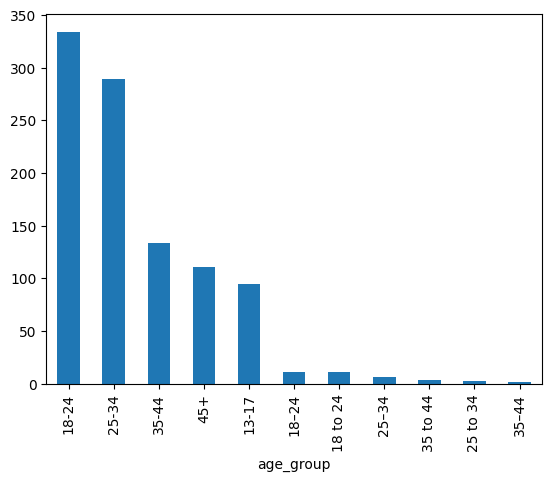

In [425]:
df_viewers["age_group"].value_counts().plot(kind="bar")

#### Let us fix this

We can combine some bins to fix this issue. I also posted this on Canvas.

<Axes: xlabel='age_group'>

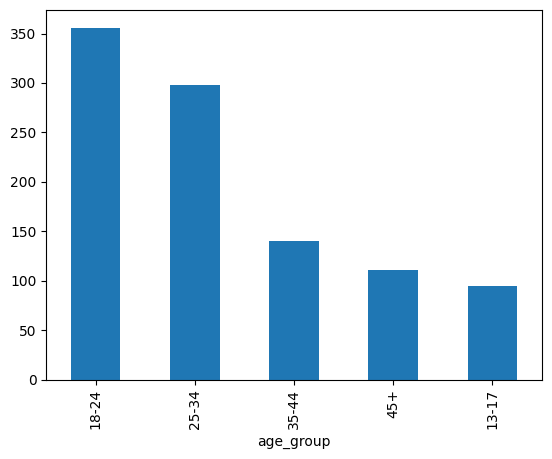

In [426]:
# From now on, we can use this df for our analysis
df_viewers_age_fixed = df_viewers.replace({"18 to 24" : "18-24", "18–24" : "18-24", "25 to 34" : "25-34", "25–34" : "25-34", "35 to 44" : "35-44", "35–44" : "35-44" })
df_viewers_age_fixed["age_group"].value_counts().plot(kind="bar")

### Observing implausible values in `subscription`

In [427]:
subscription_viewers = df_viewers_age_fixed["subscription_tier"].value_counts()
display(subscription_viewers)

subscription_tier
free          578
tier1         243
tier2         100
tier3          49
premium        10
none            7
TIER1           5
free trial      4
tier4           4
Name: count, dtype: int64

According to the internet, Twitch only has these three tiers: Tier1, Tier2, and Tier3. It offers trial periods, so we will treat `free trial` is valid - I will just change it to `free_trial` for conssitency. `free` isn't a thing, so it will be combined with `none`. `tier4` and `premium` don't exist, so I will just cap them to maximum, which is `trial3`.

In [428]:
df_viewers_all_fixed = df_viewers_age_fixed.replace({"free" : "none", "TIER1" : "tier1", "free trial" : "free_trial", "tier4" : "tier3", "premium" : "tier3"})
display(df_viewers_all_fixed["subscription_tier"].value_counts())

subscription_tier
none          585
tier1         248
tier2         100
tier3          63
free_trial      4
Name: count, dtype: int64

## Task 2 summary report

There are three ways in which I inspected the data. Firstly, I performed a rough visual inspection by looking through the dataframe. Then, depending on the type of data, I looked at the summary statistics using `df.describe()`, where I could see extreme values for the numerical variables. I also listed the unique data points for categorical data to see what categories exist and looked at min/max, count of negative/missing values. Some of these issues were already visible in part 1.

If the affected rows are little in number, I will remove them.

The issues found are listed below. All of these are errors/systemic problem, not outliers:

#### `sessions.csv`
- No issues found.

#### `streamers.csv`
- 5 negative values in the `total_followers` column. I will remove these rows. They are few enough for me to continue my analysis without them.
- 8 missing values in the `languages` column. I will remove these rows.

#### `streams.csv`
- 50 missing values in the `category` column. I will remove these rows.
- 80 missing values in the `peak_viewers` column. I will remove these rows.
- 40 negative values in `peak_viewers` column. I will remove these rows.

#### `viewers.csv`
- 80 missing missing values in `country` column. And 38 entries with `other`. Though `other` isn't necessarily an issue, just pointing it out. I replaced `missing` with `other`.
- 5 entries with `subscription` = `TIER1` instead of `tier1`. Furthermore, the subscription tiers here don't match the tiers twitch has. This has been discussed on Canvas and Discord. I fixed this above by combining some of the fields.
- Repetitions and duplicates in `age_group`. Like `18 to 24` and `18-24`. It is described above and in more detail in Canvas and Discord discussions. I fixed them above by combining some of the age groups.

### Common sense/heuristics
1. Stream end time being earlier than stream start time. That is theoretically not possible.
2. A streamer running two streams with overlapping times (see last section "Data Detective"). Twitch doesn't allow a streamer to have > 1 concurrent stream.
3. A viewer with an account age larger than the age of twitch - for example, 20 years. That would be impossible.

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

### Histogram and summary stats of total followers of `streamers`

Text(0, 0.5, 'Count')

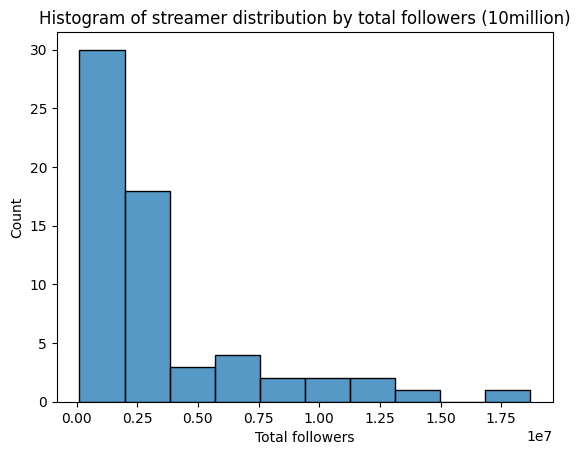

In [429]:
plt.figure()
sns.histplot(df_streamers, x="total_followers", bins=10)
plt.title("Histogram of streamer distribution by total followers (10million)")
plt.xlabel("Total followers")
plt.ylabel("Count")

In [430]:
print("Given below is 5-number summary of total followers")
display(df_streamers["total_followers"].describe())

frequencies = df_streamers["total_followers"].value_counts(bins=10)
print("Given below is the frequency distribution of the total followers")
display(frequencies)

Given below is 5-number summary of total followers


count    6.300000e+01
mean     3.400635e+06
std      3.825520e+06
min      1.200000e+05
25%      9.150000e+05
50%      2.100000e+06
75%      3.750000e+06
max      1.870000e+07
Name: total_followers, dtype: float64

Given below is the frequency distribution of the total followers


(101419.999, 1978000.0]     30
(1978000.0, 3836000.0]      18
(5694000.0, 7552000.0]       4
(3836000.0, 5694000.0]       3
(7552000.0, 9410000.0]       2
(9410000.0, 11268000.0]      2
(11268000.0, 13126000.0]     2
(13126000.0, 14984000.0]     1
(16842000.0, 18700000.0]     1
(14984000.0, 16842000.0]     0
Name: count, dtype: int64

### Bar chart and summary stats of category of `streamers`

Text(0, 0.5, 'Count')

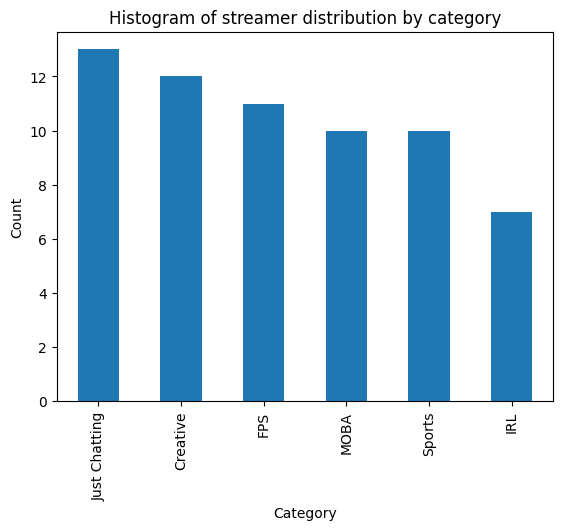

In [431]:
plt.figure()
df_streamers["category"].value_counts().plot(kind="bar")
plt.title("Histogram of streamer distribution by category")
plt.xlabel("Category")
plt.ylabel("Count")

In [432]:
categories = df_streamers["category"].value_counts()
print("Given below is the distribution of the streamer by categories")
display(categories)

Given below is the distribution of the streamer by categories


category
Just Chatting    13
Creative         12
FPS              11
MOBA             10
Sports           10
IRL               7
Name: count, dtype: int64

### Bar chart and summary stats of language of `streamers`

Text(0, 0.5, 'Count')

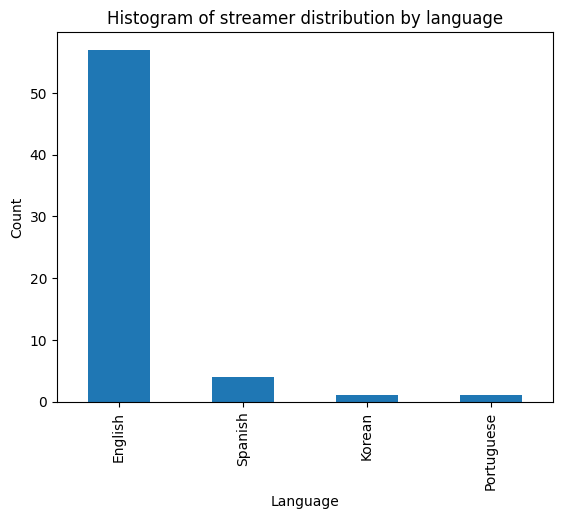

In [433]:
plt.figure()
df_streamers["language"].value_counts().plot(kind="bar")
plt.title("Histogram of streamer distribution by language")
plt.xlabel("Language")
plt.ylabel("Count")

In [434]:
languages = df_streamers["language"].value_counts()
print("Given below is the distribution of streamer language")
display(languages)

Given below is the distribution of streamer language


language
English       57
Spanish        4
Korean         1
Portuguese     1
Name: count, dtype: int64

### Bar chart and summary stats of categories of `streams`

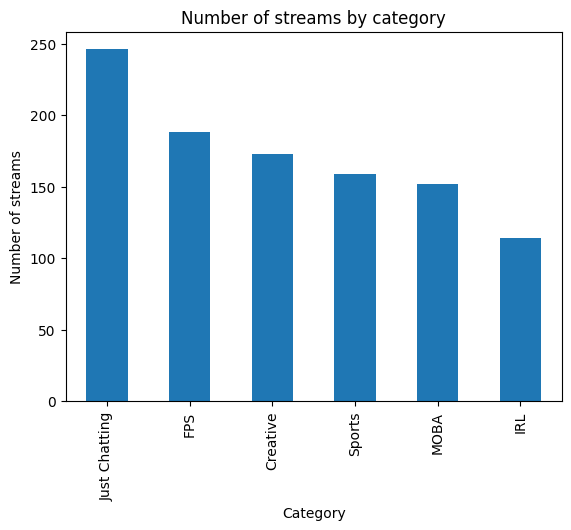

In [435]:
plt.figure()
df_streams["category"].value_counts().plot(kind="bar")
plt.title("Number of streams by category")
plt.xlabel("Category")
plt.ylabel("Number of streams")
plt.show()

In [436]:
categories_streams = df_streams["category"].value_counts()
print("Given below is the distribution of stream categories")
display(categories_streams)

Given below is the distribution of stream categories


category
Just Chatting    246
FPS              188
Creative         173
Sports           159
MOBA             152
IRL              114
Name: count, dtype: int64

### Histogram and summary stats of the distribution of duration of `streams`

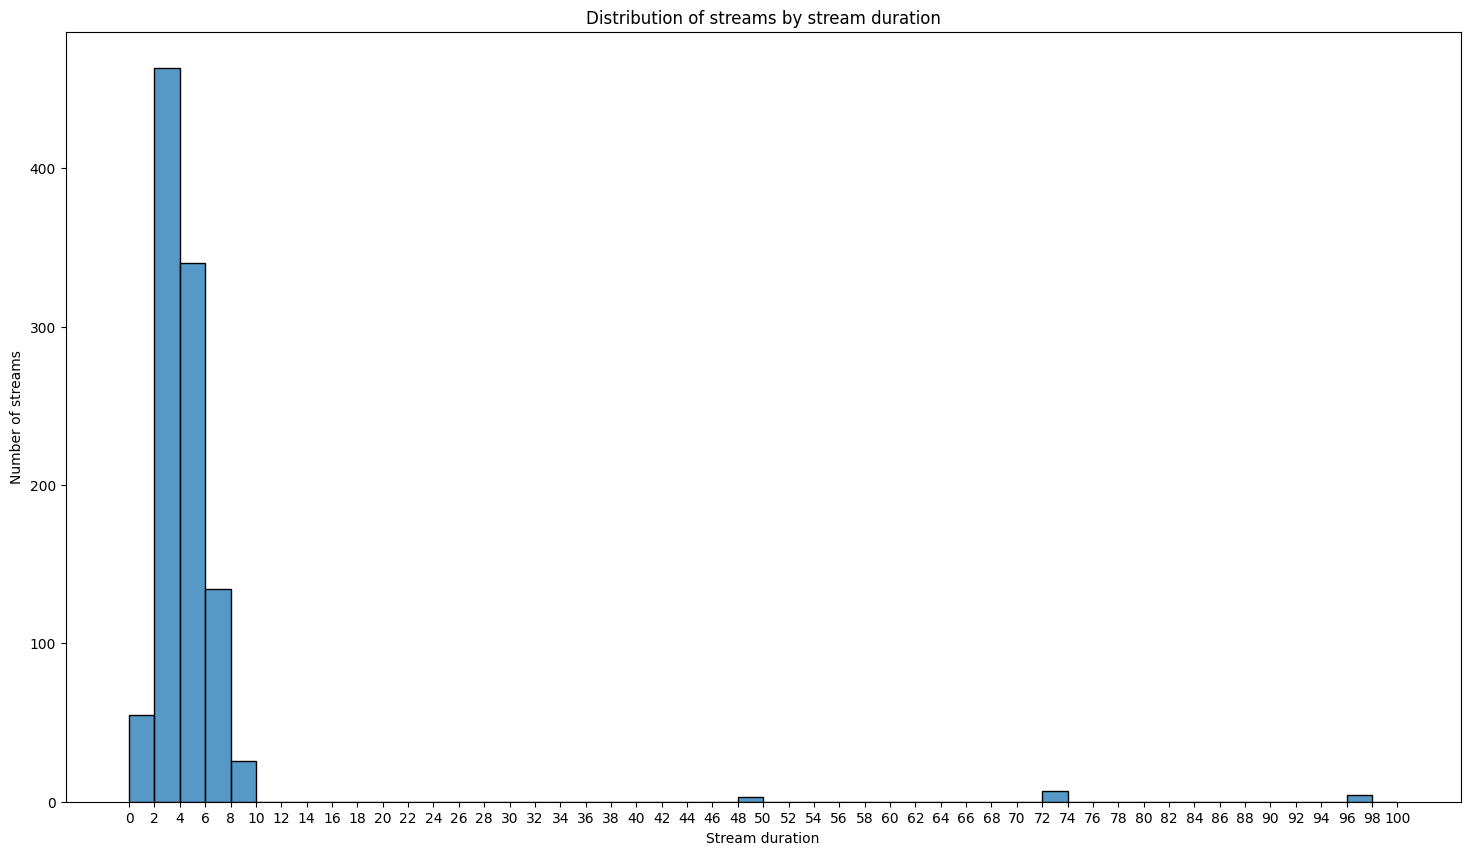

In [437]:
fig, ax = plt.subplots(figsize=(18,10))
bin_edges = np.arange(0, 101, 2)
plot = sns.histplot(df_streams, x="stream_duration_hrs", bins=bin_edges)
plot.set_xticks(bin_edges)
plt.title("Distribution of streams by stream duration")
plt.xlabel("Stream duration")
plt.ylabel("Number of streams")
plt.show()

In [438]:
print("Given below is 5-number summary of total stream duration")
display(df_streams["stream_duration_hrs"].describe())

distribution_duration = df_streams["stream_duration_hrs"].value_counts(bins=bin_edges)
print("Given below is the frequency distribution of the streams duration")
display(distribution_duration)

Given below is 5-number summary of total stream duration


count    1032.000000
mean        4.721415
std         8.481374
min         1.500000
25%         2.500000
50%         3.000000
75%         5.000000
max        96.000000
Name: stream_duration_hrs, dtype: float64

Given below is the frequency distribution of the streams duration


(2.0, 4.0]       549
(4.0, 6.0]       228
(-0.001, 2.0]    168
(6.0, 8.0]        73
(70.0, 72.0]       7
(94.0, 96.0]       4
(46.0, 48.0]       3
(8.0, 10.0]        0
(10.0, 12.0]       0
(12.0, 14.0]       0
(14.0, 16.0]       0
(16.0, 18.0]       0
(18.0, 20.0]       0
(20.0, 22.0]       0
(22.0, 24.0]       0
(24.0, 26.0]       0
(26.0, 28.0]       0
(28.0, 30.0]       0
(30.0, 32.0]       0
(32.0, 34.0]       0
(34.0, 36.0]       0
(36.0, 38.0]       0
(38.0, 40.0]       0
(40.0, 42.0]       0
(42.0, 44.0]       0
(44.0, 46.0]       0
(48.0, 50.0]       0
(50.0, 52.0]       0
(52.0, 54.0]       0
(54.0, 56.0]       0
(56.0, 58.0]       0
(58.0, 60.0]       0
(60.0, 62.0]       0
(62.0, 64.0]       0
(64.0, 66.0]       0
(66.0, 68.0]       0
(68.0, 70.0]       0
(72.0, 74.0]       0
(74.0, 76.0]       0
(76.0, 78.0]       0
(78.0, 80.0]       0
(80.0, 82.0]       0
(82.0, 84.0]       0
(84.0, 86.0]       0
(86.0, 88.0]       0
(88.0, 90.0]       0
(90.0, 92.0]       0
(92.0, 94.0] 

### Histogram and summary stats of the distribution of peak viewers of `streams`

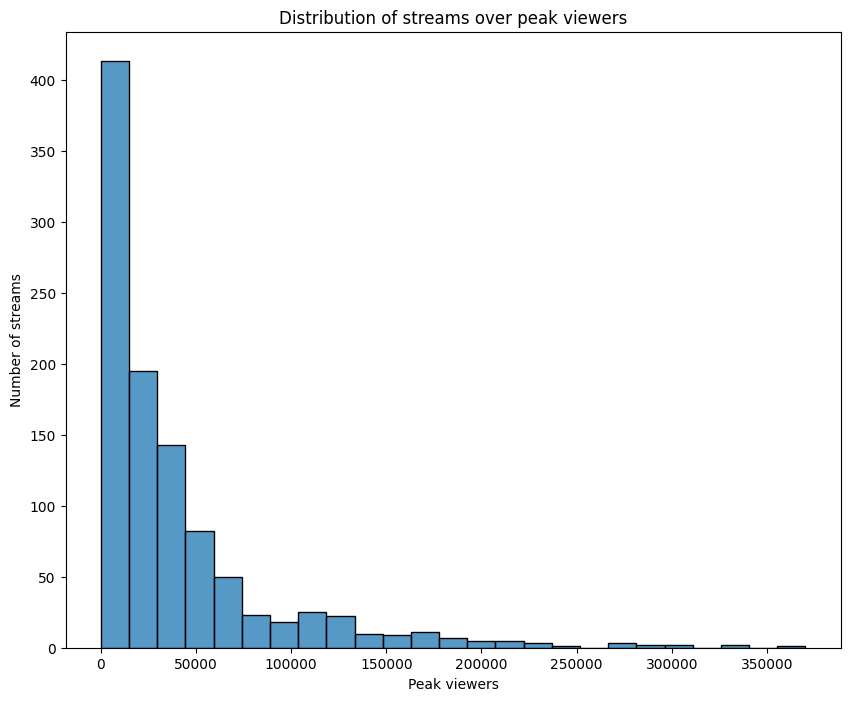

In [439]:
fig, ax = plt.subplots(figsize=(10,8))
peak_viewers_bin_edges = np.arange(0, 400000, 10000)
sns.histplot(df_streams, x="peak_viewers", bins=25)
plt.title("Distribution of streams over peak viewers")
plt.xlabel("Peak viewers")
plt.ylabel("Number of streams")
plt.show()

In [440]:
print("Given below is 5-number summary of peak_viewer")
display(df_streams["peak_viewers"].describe())

distribution_peak_viewers = df_streams["peak_viewers"].value_counts(bins=peak_viewers_bin_edges)
print("Given below is the frequency distribution of the peakviewers")
display(distribution_peak_viewers)

Given below is 5-number summary of peak_viewer


count      1032.000000
mean      39595.275194
std       50706.778736
min          57.000000
25%        9100.250000
50%       21187.500000
75%       48559.500000
max      370165.000000
Name: peak_viewers, dtype: float64

Given below is the frequency distribution of the peakviewers


(-0.001, 10000.0]       284
(10000.0, 20000.0]      214
(20000.0, 30000.0]      115
(30000.0, 40000.0]      107
(40000.0, 50000.0]       58
(50000.0, 60000.0]       55
(60000.0, 70000.0]       38
(70000.0, 80000.0]       22
(100000.0, 110000.0]     22
(120000.0, 130000.0]     15
(80000.0, 90000.0]       13
(90000.0, 100000.0]      12
(110000.0, 120000.0]     12
(160000.0, 170000.0]     10
(140000.0, 150000.0]      8
(130000.0, 140000.0]      7
(150000.0, 160000.0]      6
(180000.0, 190000.0]      5
(170000.0, 180000.0]      4
(200000.0, 210000.0]      4
(230000.0, 240000.0]      4
(190000.0, 200000.0]      3
(210000.0, 220000.0]      3
(290000.0, 300000.0]      3
(270000.0, 280000.0]      2
(330000.0, 340000.0]      2
(220000.0, 230000.0]      1
(260000.0, 270000.0]      1
(280000.0, 290000.0]      1
(370000.0, 380000.0]      1
(240000.0, 250000.0]      0
(250000.0, 260000.0]      0
(300000.0, 310000.0]      0
(310000.0, 320000.0]      0
(320000.0, 330000.0]      0
(340000.0, 350000.0]

### Bar chart and summary stats of `viewers` across age groups

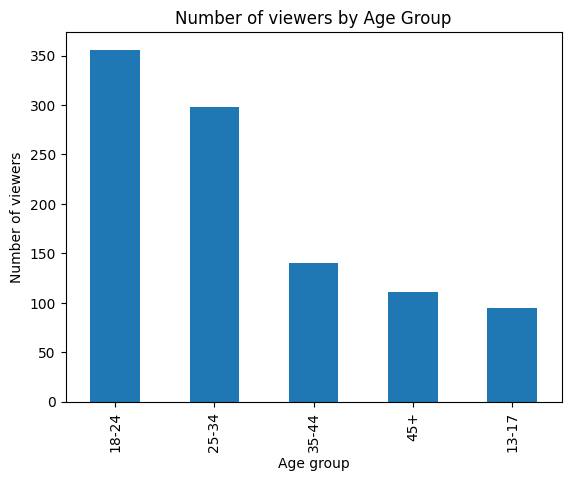

In [441]:
plt.figure()
df_viewers_all_fixed["age_group"].value_counts().plot(kind="bar")
plt.title("Number of viewers by Age Group")
plt.xlabel("Age group")
plt.ylabel("Number of viewers")
plt.show()

In [442]:
distribution_viewer_age = df_viewers_all_fixed["age_group"].value_counts()
print("Given below is the distribtuion of viewers by age group")
display(distribution_viewer_age)

Given below is the distribtuion of viewers by age group


age_group
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64

### Bar chart and summary stats of distribution of `viewers` across countries

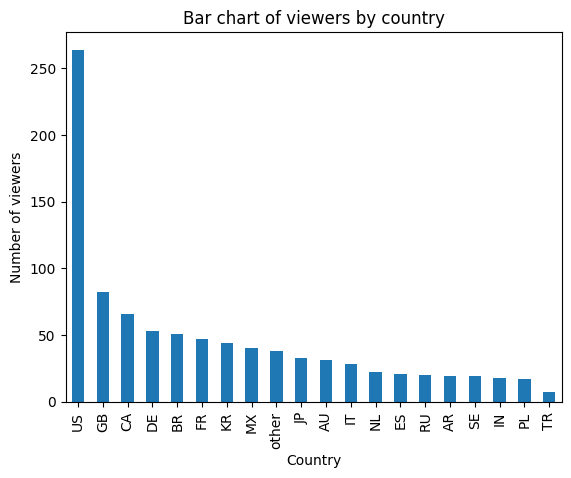

In [443]:
plt.figure()
df_viewers_all_fixed["country"].value_counts().plot(kind="bar")
plt.title("Bar chart of viewers by country")
plt.xlabel("Country")
plt.ylabel("Number of viewers")
plt.show()


In [444]:
distribution_viewer_countries = df_viewers_all_fixed["country"].value_counts()
print("Given below is the distribution viewer countries")
display(distribution_viewer_countries)

Given below is the distribution viewer countries


country
US       264
GB        82
CA        66
DE        53
BR        51
FR        47
KR        44
MX        40
other     38
JP        33
AU        31
IT        28
NL        22
ES        21
RU        20
AR        19
SE        19
IN        18
PL        17
TR         7
Name: count, dtype: int64

### Grouped/clustered barchart of viewers by age group and categories they prefer

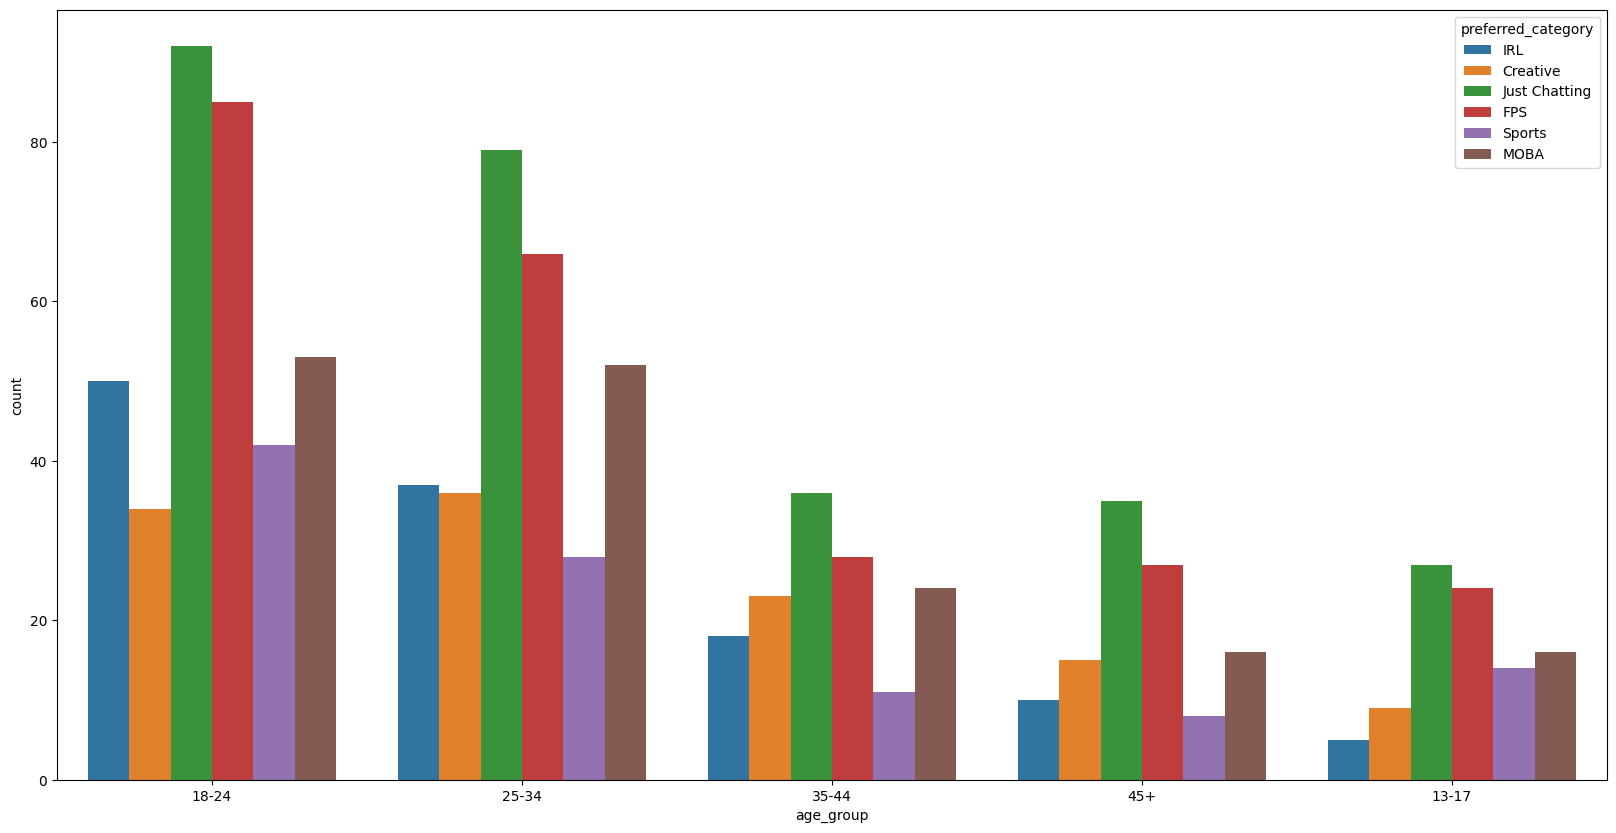

In [445]:
fig, ax = plt.subplots(figsize=(20,10))
sns.countplot(df_viewers_all_fixed, x="age_group", hue="preferred_category")
plt.show()

### Bar chart and summary stats of `viewers` across different subscription tiers

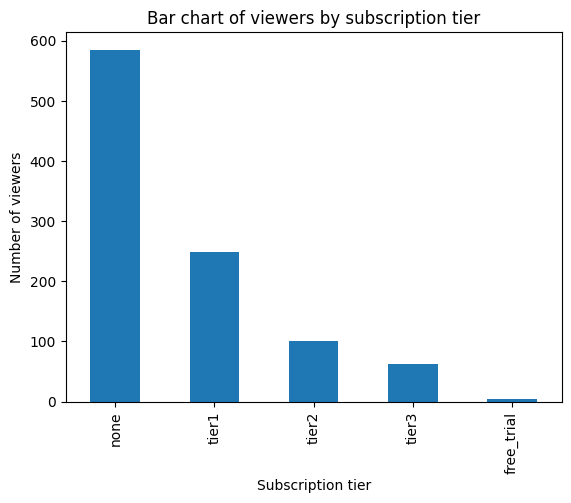

In [446]:
plt.figure()
df_viewers_all_fixed["subscription_tier"].value_counts().plot(kind="bar")
plt.title("Bar chart of viewers by subscription tier")
plt.xlabel("Subscription tier")
plt.ylabel("Number of viewers")
plt.show()

In [447]:
distribution_viewers_subscription = df_viewers_all_fixed["subscription_tier"].value_counts()
print("Given below is the distribution of viewers by subscription tier")
display(distribution_viewers_subscription)

Given below is the distribution of viewers by subscription tier


subscription_tier
none          585
tier1         248
tier2         100
tier3          63
free_trial      4
Name: count, dtype: int64

### Task 3 Summary report

Nothing much to report, as the images are more effective in telling the story from the data.

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

For check-ins, I will use `bits_cheered` and `chat_messages_sent` in `sessions.csv`. I will create a new column in `df_sessions` called `total_checkins`. `total_checkins` = `bits_cheered` + `chat_messages_sent`

In [448]:
df_sessions["total_checkins"] = df_sessions["chat_messages_sent"] + df_sessions["bits_cheered"]
display(df_sessions["total_checkins"].describe())
display(df_sessions)

count    22825.000000
mean       404.867952
std       1571.949148
min          0.000000
25%          0.000000
50%          2.000000
75%          8.000000
max      10017.000000
Name: total_checkins, dtype: float64

,session_id,viewer_id,streamer_id,stream_id,started_at,started_at_unix_time,ended_at,ended_at_unix_time,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during,total_checkins
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,1705605360,2024-01-18 20:28:00,1705609680,72,0,0,False,False,0
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,1704388260,2024-01-04 19:41:00,1704397260,150,11,0,False,False,11
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,1708009860,2024-02-15 16:53:00,1708015980,102,5,0,False,False,5
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,1705607940,2024-01-18 20:56:00,1705611360,57,3,9663,False,False,9666
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,1710878880,2024-03-19 20:22:00,1710879720,14,7,0,False,False,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22820,SES022821,VWR00856,STR0005,SM00083,2024-01-16 18:51:00,1705431060,2024-01-16 22:17:00,1705443420,206,31,0,False,False,31
22821,SES022822,VWR00985,STR0013,SM00200,2024-01-08 20:28:00,1704745680,2024-01-08 20:52:00,1704747120,24,1,0,False,False,1
22822,SES022823,VWR00645,STR0045,SM00711,2024-03-26 04:15:00,1711426500,2024-03-26 04:58:00,1711429080,43,1,0,False,False,1
22823,SES022824,VWR00291,STR0005,SM00078,2024-01-11 20:02:00,1705003320,2024-01-11 21:01:00,1705006860,59,2,0,False,False,2


To make it easier to access the streamer category, I can do that with `pd.merge`

In [449]:
df_sessions_with_categories = pd.merge(df_sessions, df_streamers, on="streamer_id", how="inner")
display(df_sessions_with_categories)

,session_id,viewer_id,streamer_id,stream_id,started_at,started_at_unix_time,ended_at,ended_at_unix_time,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during,total_checkins,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,1705605360,2024-01-18 20:28:00,1705609680,72,0,0,False,False,0,PointCrow,Creative,English,True,890000,9938
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,1704388260,2024-01-04 19:41:00,1704397260,150,11,0,False,False,11,Caps,MOBA,English,True,980000,6679
2,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,1705607940,2024-01-18 20:56:00,1705611360,57,3,9663,False,False,9666,s1mple,FPS,English,True,3600000,48998
3,SES000006,VWR00860,STR0056,SM00877,2024-01-07 00:41:00,1704588060,2024-01-07 02:13:00,1704593580,92,13,0,False,False,13,Alpharad,Creative,English,True,760000,9233
4,SES000007,VWR00925,STR0052,SM00828,2024-01-29 21:41:00,1706564460,2024-01-30 01:59:00,1706579940,258,13,0,False,False,13,Northernlion,Creative,English,True,3100000,6496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18748,SES022820,VWR00842,STR0059,SM00933,2024-02-13 21:37:00,1707860220,2024-02-13 23:35:00,1707867300,118,1,0,False,False,1,GrandPOObear,Creative,English,True,720000,2748
18749,SES022821,VWR00856,STR0005,SM00083,2024-01-16 18:51:00,1705431060,2024-01-16 22:17:00,1705443420,206,31,0,False,False,31,Mizkif,Just Chatting,English,True,2100000,6771
18750,SES022823,VWR00645,STR0045,SM00711,2024-03-26 04:15:00,1711426500,2024-03-26 04:58:00,1711429080,43,1,0,False,False,1,Nmplol,IRL,English,True,1600000,20511
18751,SES022824,VWR00291,STR0005,SM00078,2024-01-11 20:02:00,1705003320,2024-01-11 21:01:00,1705006860,59,2,0,False,False,2,Mizkif,Just Chatting,English,True,2100000,6771


## Correlation (pearson) of streamer features and number of check-ins

,total_followers,avg_concurrent_viewers,total_checkins
total_followers,1.000000,0.868945,0.009808
avg_concurrent_viewers,0.868945,1.000000,0.009940
total_checkins,0.009808,0.009940,1.000000


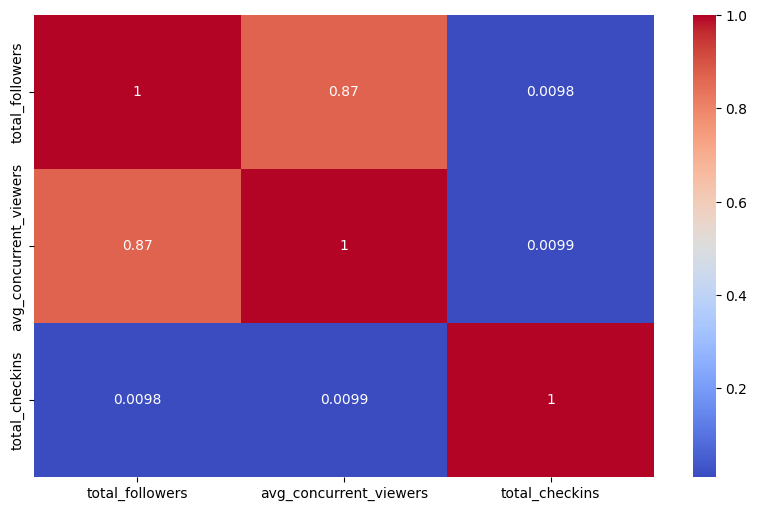

In [396]:
streamer_corr_columns = ["total_followers", "avg_concurrent_viewers", "total_checkins"]
correlation_streamer = df_sessions_with_categories[streamer_corr_columns].corr()
display(correlation_streamer)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(correlation_streamer, annot=True, cmap="coolwarm")
plt.show()

## Correlation (spearman) of streamer features and number of check-ins

,total_followers,avg_concurrent_viewers,total_checkins
total_followers,1.000000,0.889459,0.016424
avg_concurrent_viewers,0.889459,1.000000,0.016956
total_checkins,0.016424,0.016956,1.000000


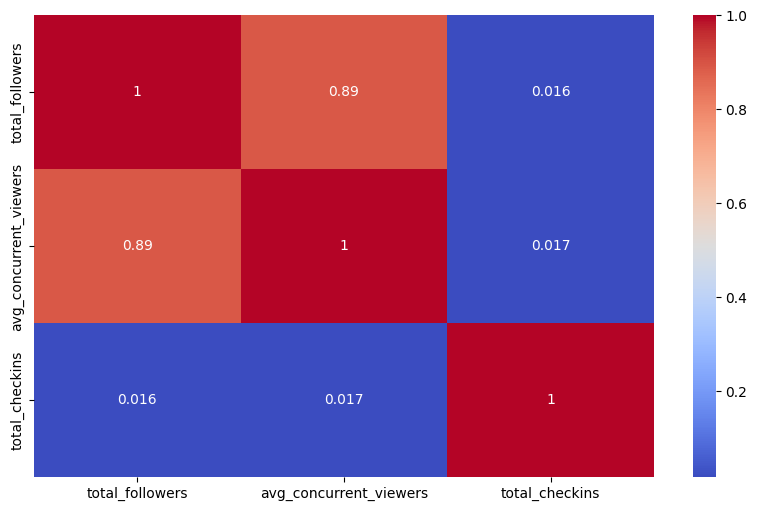

In [397]:
streamer_corr_columns = ["total_followers", "avg_concurrent_viewers", "total_checkins"]
correlation_streamer_spearman = df_sessions_with_categories[streamer_corr_columns].corr(method="spearman")
display(correlation_streamer_spearman)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(correlation_streamer_spearman, annot=True, cmap="coolwarm")
plt.show()

## Spearman vs pearson

Pearson is to be used for primarily ordinal data and non linear relationships. As a result it is not really appropriate here. So we won't use at.

### Task 5 Summary report

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

## Viewer behaviour based on age-group

For this, I would like to find the total number of sessions participated by the user. I can merge `df_sessions` with `df_viewers`. And add a column for total sessions by this viewer.

In [472]:
df_sessions_with_viewer_age = pd.merge(df_sessions, df_viewers_all_fixed, on="viewer_id", how="inner")
df_sessions_with_viewer_age["sessions_by_viewer"] = df_sessions_with_viewer_age.groupby("viewer_id")["viewer_id"].transform("count")
display(df_sessions_with_viewer_age)

,session_id,viewer_id,streamer_id,stream_id,started_at,started_at_unix_time,ended_at,ended_at_unix_time,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during,total_checkins,age_group,country,account_age_days,subscription_tier,preferred_category,sessions_by_viewer
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,1705605360,2024-01-18 20:28:00,1705609680,72,0,0,False,False,0,13-17,IN,1875,none,Just Chatting,85
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,1704388260,2024-01-04 19:41:00,1704397260,150,11,0,False,False,11,18-24,RU,2085,tier1,FPS,32
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,1708009860,2024-02-15 16:53:00,1708015980,102,5,0,False,False,5,18-24,CA,1762,tier1,MOBA,40
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,1705607940,2024-01-18 20:56:00,1705611360,57,3,9663,False,False,9666,18-24,US,258,none,Just Chatting,89
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,1710878880,2024-03-19 20:22:00,1710879720,14,7,0,False,False,7,45+,CA,2765,tier2,Just Chatting,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22820,SES022821,VWR00856,STR0005,SM00083,2024-01-16 18:51:00,1705431060,2024-01-16 22:17:00,1705443420,206,31,0,False,False,31,45+,CA,603,tier1,FPS,72
22821,SES022822,VWR00985,STR0013,SM00200,2024-01-08 20:28:00,1704745680,2024-01-08 20:52:00,1704747120,24,1,0,False,False,1,18-24,other,452,none,FPS,79
22822,SES022823,VWR00645,STR0045,SM00711,2024-03-26 04:15:00,1711426500,2024-03-26 04:58:00,1711429080,43,1,0,False,False,1,45+,AU,1889,none,IRL,20
22823,SES022824,VWR00291,STR0005,SM00078,2024-01-11 20:02:00,1705003320,2024-01-11 21:01:00,1705006860,59,2,0,False,False,2,45+,SE,3170,tier1,Just Chatting,5


Text(0, 0.5, 'Total Sessions')

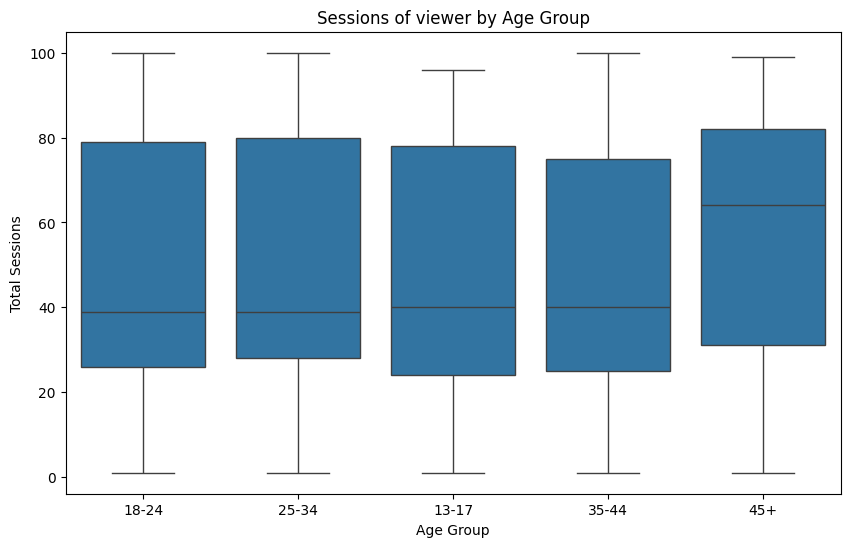

In [481]:
order = df_sessions_with_viewer_age.groupby("age_group")["sessions_by_viewer"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df_sessions_with_viewer_age, y="sessions_by_viewer", x="age_group", order=order)
plt.title("Sessions of viewer by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sessions")


## Viewer behaviour on subscription tier

Text(0, 0.5, 'Total Sessions')

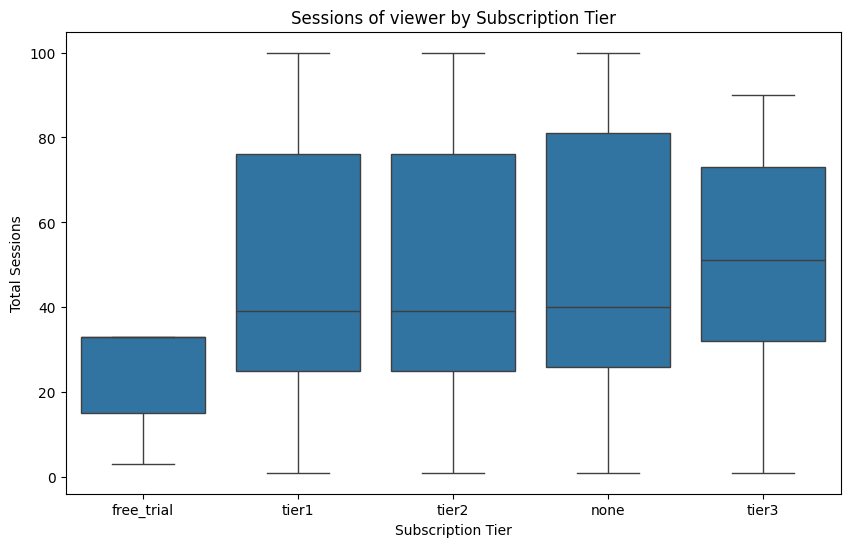

In [484]:
order = df_sessions_with_viewer_age.groupby("subscription_tier")["sessions_by_viewer"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df_sessions_with_viewer_age, y="sessions_by_viewer", x="subscription_tier", order=order)
plt.title("Sessions of viewer by Subscription Tier")
plt.xlabel("Subscription Tier")
plt.ylabel("Total Sessions")

## Viewer behaviour on country

Text(0, 0.5, 'Total Sessions')

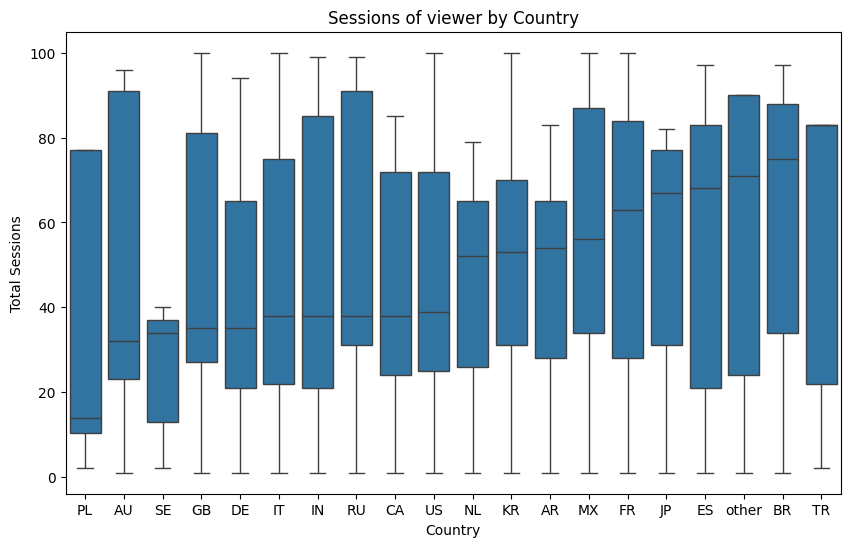

In [490]:
order = df_sessions_with_viewer_age.groupby("country")["sessions_by_viewer"].median().sort_values().index
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df_sessions_with_viewer_age, y="sessions_by_viewer", x="country", order=order)
plt.title("Sessions of viewer by Country")
plt.xlabel("Country")
plt.ylabel("Total Sessions")

### Task 6 Summary report

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


## Does a viewerr's age affect their preferred category? How many users in each age x category combination?

,age_group,preferred_category,count
0,13-17,Creative,269
1,13-17,FPS,355
2,13-17,IRL,137
3,13-17,Just Chatting,694
4,13-17,MOBA,312
5,13-17,Sports,334
6,18-24,Creative,903
7,18-24,FPS,1824
8,18-24,IRL,1017
9,18-24,Just Chatting,2484


preferred_category,Creative,FPS,IRL,Just Chatting,MOBA,Sports
age_group,,,,,,
13-17,269,355,137,694,312,334
18-24,903,1824,1017,2484,820,950
25-34,610,1585,914,1701,1231,709
35-44,541,518,426,916,398,356
45+,300,780,302,667,524,248


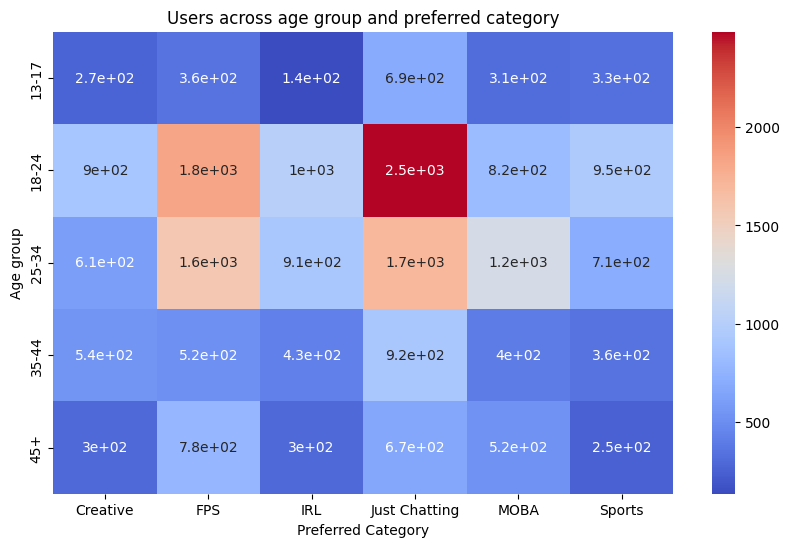

In [525]:
# task 7 code start here
counts_series = df_sessions_with_viewer_age.groupby(["age_group", "preferred_category"]).size().reset_index(name="count")
display(counts_series)
heatmap = pd.crosstab(df_sessions_with_viewer_age["age_group"], df_sessions_with_viewer_age["preferred_category"])
display(heatmap)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(heatmap, cmap="coolwarm", annot=True)
plt.title("Users across age group and preferred category")
plt.xlabel("Preferred Category")
plt.ylabel("Age group")
plt.show()

## What are the mean age for each subscription tier?

age_group
13-17    1845.442105
18-24    1860.724719
25-34    1852.580537
35-44    1861.171429
45+      2078.837838
Name: account_age_days, dtype: float64

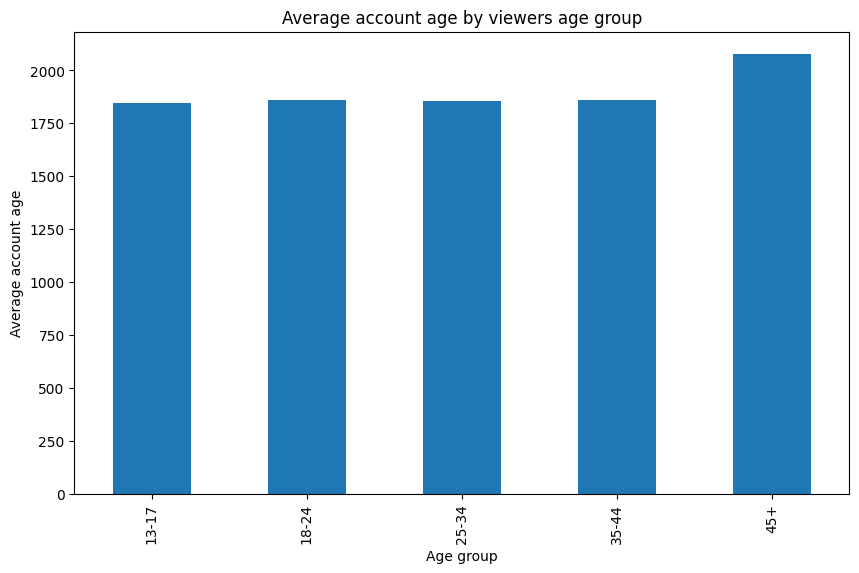

In [537]:
viewers_by_tier = df_viewers_all_fixed.groupby("age_group")["account_age_days"].mean()
display(viewers_by_tier)
plt.figure(figsize=(10,6))
viewers_by_tier.plot(kind="bar")
plt.title("Average account age by viewers age group")
plt.xlabel("Age group")
plt.ylabel("Average account age")
plt.show()

## What are the median age for each subscription tier?

age_group
13-17    1875.0
18-24    1990.0
25-34    1949.5
35-44    1895.0
45+      2424.0
Name: account_age_days, dtype: float64

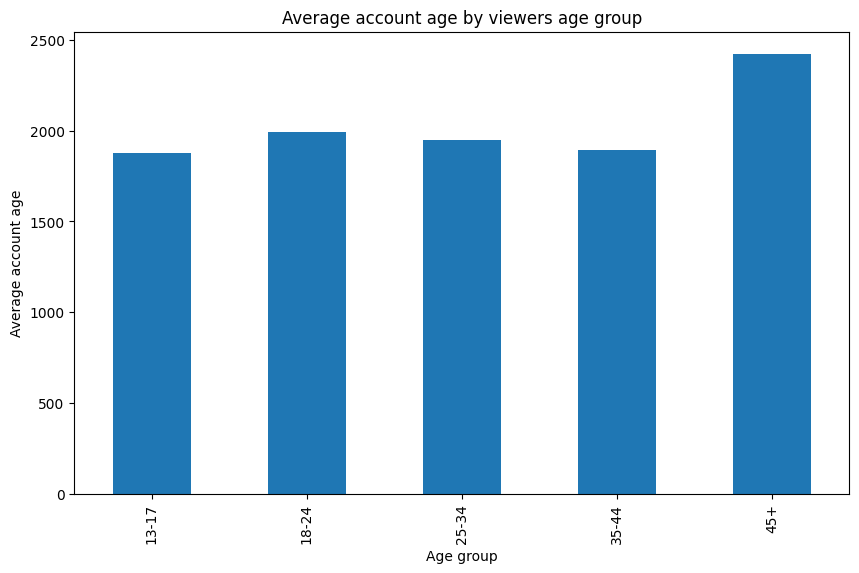

In [540]:
viewers_by_tier = df_viewers_all_fixed.groupby("age_group")["account_age_days"].median()
display(viewers_by_tier)
plt.figure(figsize=(10,6))
viewers_by_tier.plot(kind="bar")
plt.title("Average account age by viewers age group")
plt.xlabel("Age group")
plt.ylabel("Average account age")
plt.show()

### Task 7 Summary report

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  

# Some data detective stuff

## Overlapping streams by a single streamer

I want to see if there are any concurrent/overlapping streams by a certain streamer.

In [538]:
count_overlapping_streams = 0
df_streams_streamer = df_streams.groupby("streamer_id")
overlapping_streams = {"streamer_id":[], "stream_id":[], "start_time":[], "end_time":[]}
df_overlapping_streams = pd.DataFrame(overlapping_streams)
for group, dataframe in df_streams_streamer:
    for row in dataframe.itertuples():
        start = row.started_at
        end = row.ended_at
        for row_to_compare in dataframe.itertuples():
            if (row.stream_id != row_to_compare.stream_id):
                start_compare = row_to_compare.started_at
                end_compare = row_to_compare.ended_at
                i1 = pd.Interval(pd.to_datetime(start), pd.to_datetime(end))
                i2 = pd.Interval(pd.to_datetime(start_compare), pd.to_datetime(end_compare))
                if (i1.overlaps(i2)):
                    # print(f"There is an overlapping stream, by streamer {row.streamer_id} = {row_to_compare.streamer_id}. Stream ids are: {row.stream_id} and {row_to_compare.stream_id}.")
                    count_overlapping_streams +=1
                    new_row = [row.streamer_id, row.stream_id, row.started_at, row.ended_at]
                    df_overlapping_streams.loc[len(df_overlapping_streams)] = new_row

print(f"\nThere are total {count_overlapping_streams} overlapping streams")
display(df_overlapping_streams)

overlapping_timelines = px.timeline(data_frame=df_overlapping_streams, y=df_overlapping_streams["streamer_id"], x_start=df_overlapping_streams["start_time"], x_end=df_overlapping_streams["end_time"], color=df_overlapping_streams["stream_id"], width = 1000, height = 600, opacity=0.2)
overlapping_timelines.show()
    



There are total 36 overlapping streams


,streamer_id,stream_id,start_time,end_time
0,STR0001,SM00002,2024-01-28 18:00:00,2024-01-28 21:00:00
1,STR0001,SM00009,2024-01-28 17:00:00,2024-01-28 21:00:00
2,STR0007,SM00105,2024-02-18 19:00:00,2024-02-18 23:00:00
3,STR0007,SM00107,2024-02-18 18:00:00,2024-02-18 22:00:00
4,STR0008,SM00117,2024-03-07 16:00:00,2024-03-07 22:00:00
5,STR0008,SM00118,2024-03-07 15:00:00,2024-03-07 20:00:00
6,STR0009,SM00133,2024-01-18 15:00:00,2024-01-18 19:00:00
7,STR0009,SM00142,2024-01-18 11:00:00,2024-01-18 17:00:00
8,STR0015,SM00230,2024-02-16 08:00:00,2024-02-16 10:30:00
9,STR0015,SM00237,2024-02-16 10:00:00,2024-02-16 12:30:00


As we can see above, there are 56 instances of streamers doing more than one concurrent stream.

## Young users with long account age

There are some users in age group 13-17 with account age > 3000 days. That doesn't seem good given minimum age requirements.

In [539]:
implausible_age = df_viewers_all_fixed.loc[(df_viewers_all_fixed["age_group"] == "13-17") & (df_viewers_all_fixed["account_age_days"] > 3000)]
display(implausible_age)

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
63,VWR00064,13-17,US,3177,tier2,FPS
107,VWR00108,13-17,AU,3437,none,Just Chatting
179,VWR00180,13-17,US,3209,none,Just Chatting
219,VWR00220,13-17,AR,3003,none,MOBA
223,VWR00224,13-17,US,3013,none,Sports
229,VWR00230,13-17,NL,3595,tier3,FPS
261,VWR00262,13-17,AU,3462,none,MOBA
355,VWR00356,13-17,MX,3518,none,FPS
376,VWR00377,13-17,GB,3247,tier1,FPS
383,VWR00384,13-17,KR,3636,none,FPS
